# Generate Evaluation Prompt

In [6]:
from tqdm import tqdm

In [1]:
import json
import os
import sys
import importlib.util
import pandas as pd
from dotenv import load_dotenv
from google import genai

# Load environment variables from a .env file
load_dotenv(override=True)
api_key = os.getenv("GEMINI_API_KEY")

# The client gets the API key from the environment variable `GEMINI_API_KEY`.
client = genai.Client()

/Users/mdhasebulhasan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [46]:
def load_data_from_excel(excel_path, sheet_1_name, column_mapping, sheet_2_name):
    """
    Loads data from a specified sheet in an Excel file.

    Args:
        excel_path (str): The file path for the Excel file.
        sheet_1_name (str): The name of the sheet 1 to read from.
        column_mapping (dict): Maps template keys to Excel column names. If a column name is None, a default value is used.
        sheet_2_name (str): The name of the sheet 2 to read from.                       

    Returns:
        list: A list of dictionaries, where each dictionary contains the data for one prompt (one row from the Excel sheet). Returns None on error.
    """
    # print(f"Loading data from '{excel_path}' (Sheet: '{sheet_1_name}')...")
    try:
        df = pd.read_excel(excel_path, sheet_name=sheet_1_name)
        df2 = pd.read_excel(excel_path, sheet_name=sheet_2_name)
        dict_list = df.to_dict('records')
        dict_array = {}
        for d in dict_list:
            dict_array[d['id']] = d
        df2['Origin'] = df2['Origin'].astype(int) if df2['Origin'].dtype != None else df2['Origin']
        dict_list2 = df2.to_dict('records')
        # Fill any empty cells with an empty string to avoid errors
        # df.fillna("", inplace=True)
    except FileNotFoundError:
        print(f"Error: The file '{excel_path}' was not found.")
        return None
    except Exception as e:
        print(f"Error reading Excel file: {e}")
        return None

    all_data = []
    
    # Iterate over each row in the DataFrame
    for index in range(44,72):
        parent_idx = dict_list2[index]['Origin']
        data = dict_list2[index]
        additional_data = dict_array[parent_idx]
        # print(f"  - Processing row {index + 1}...")
        for template_key, dict_column in column_mapping.items():
            if dict_column and dict_column in additional_data.keys():
                # Get data from the specified excel column
                value = additional_data[dict_column]
                # Ensure value is a string and strip leading/trailing whitespace
                data[template_key] = str(value).strip()
            else:
                # Handle keys that are in the template but not mapped to an Excel column
                if template_key == "role_name":
                    data[template_key] = data["profile"].split(',')[0].strip()
        all_data.append(data)
    return all_data

In [47]:
def generate_prompt(template_path, data):
    """
    Generates a complete prompt by replacing placeholders in a template with data.
    The template is loaded from a 'prompt' variable within the Python file specified.

    Args:
        template_path (str): The file path for the prompt template Python file.
        data (dict): A dictionary containing the data to fill in the template.

    Returns:
        str: The completed prompt with all placeholders replaced, or an error message.
    """
    # print(f"\nLoading prompt template from variable in '{template_path}'...")
    try:
        # Create a module name from the file path
        module_name = os.path.splitext(os.path.basename(template_path))[0]
        
        # Create a module spec from the file path
        spec = importlib.util.spec_from_file_location(module_name, template_path)
        if spec is None:
            return f"Error: Could not create module spec for '{template_path}'. Check if the file exists and is accessible."
            
        # Create a new module based on the spec
        prompt_module = importlib.util.module_from_spec(spec)
        
        # Execute the module in its own namespace
        spec.loader.exec_module(prompt_module)
        
        # Get the 'prompt' variable from the module
        template = getattr(prompt_module, 'prompt')

    except FileNotFoundError:
        return f"Error: Template file not found at '{template_path}'"
    except AttributeError:
        return f"Error: The file '{template_path}' does not contain a 'prompt' variable."
    except Exception as e:
        return f"An unexpected error occurred while loading the template: {e}"

    try:
        # Use the format method with the data dictionary to replace placeholders
        completed_prompt = template.format(**data)
        return completed_prompt
    except KeyError as e:
        return f"Error: A key is missing in the data dictionary: {e}. Make sure all placeholders in the template are in the column_mapping."
    except Exception as e:
        return f"An unexpected error occurred during formatting: {e}"


In [51]:

# --- Configuration ---
TEMPLATE_FILE = os.path.join("Prompt", "prompt_evaluation_role.py")
EXCEL_FILE = "../../../data/de-escalation training dataset.xlsx"
SHEET_1_NAME = "synthesis_dataset"
SHEET_2_NAME = "Data_with_negative_example"

# Map the placeholders in your template file to the column names in your Excel sheet.
# If a placeholder doesn't have a corresponding column, it will get a default value.
COLUMN_MAPPING = {
    "scenario_name": "Scenario_Title",
    "Scenario_Set_up": "Scenario_Set_up",
    "profile": "Scenario_Character_Profile",
    "Scenario_recommendation_action": "Scenario_recommendation_action",
    "role_name": None,
}

# 1. Load the data from the Excel file
all_prompt_data = load_data_from_excel(EXCEL_FILE, SHEET_1_NAME, COLUMN_MAPPING, SHEET_2_NAME)
output = []

    

In [52]:
all_prompt_data

[{'ID': 45,
  'de_escalation_outccome': 'Ideal',
  'Conversation': 'Officer: Mike, right? I’m Dan. I’m just here to talk with you, man. You look like you’ve had one hell of a night.\n\nMike: Yeah.\n\nOfficer: Mind if I sit down for a minute? Looks like you could use a friend.\n\nMike: No.\n\nOfficer: Okay, that\'s fine. I\'ll just stand. I\'m not here to hurt you. My only goal is to make sure you\'re safe. Can you tell me what\'s going on?\n\nMike: Did you know that the average pub in the United States serves 15 different types of beer? My wife is also a licensed taxidermist. The Olympics are a fascinating study in human endurance. I once worked as a professional ice skater.\n\nOfficer: I\'m not sure what that has to do with things, Mike. I\'m really worried about you. I heard you\'ve been having a tough time with your wife and your job.\n\nMike: The color of the wall is beige. It is an off-white, soothing tone. It is a very calming color. Did you know that? It\'s called \'Sandstone.\'

In [53]:
if all_prompt_data:
        print(f"\nSuccessfully loaded data for {len(all_prompt_data)} prompts.")
        # Create the directory for output files if it doesn't exist
        # os.makedirs("generated_prompts", exist_ok=True)
        
        # 2. Generate a prompt for each row of data from the Excel file
        
        for i, prompt_data in tqdm(enumerate(all_prompt_data, 1), total=len(all_prompt_data)):
            out_data = {}
            final_prompt = generate_prompt(TEMPLATE_FILE, prompt_data)
            response = client.models.generate_content(
                model="gemini-2.5-flash", contents=final_prompt
            )
            # print("Raw response:", response.text)
            raw = response.text.strip()
            if raw.startswith("```json"):
                raw = raw[len("```json"):].strip()
            if raw.endswith("```"):
                raw = raw[:-3].strip()

            result_dict = json.loads(raw)
            # result_dict = json.loads(response.text)
            look_Real = result_dict['look_Real']
            score = result_dict['Score']
            # print(f"ID: {prompt_data['ID']}, look_Real: {look_Real}, Score: {score}")
            out_data['ID'] = prompt_data['ID']
            out_data['Conversation'] = prompt_data['Conversation']
            out_data['look_Real'] = prompt_data['look_Real']
            out_data['Origin'] = prompt_data['Origin']
            out_data['predicted_look_Real'] = look_Real
            out_data['Score'] = score
            output.append(out_data)


Successfully loaded data for 28 prompts.


100%|██████████| 28/28 [04:35<00:00,  9.84s/it]


In [54]:
output

[{'ID': 45,
  'Conversation': 'Officer: Mike, right? I’m Dan. I’m just here to talk with you, man. You look like you’ve had one hell of a night.\n\nMike: Yeah.\n\nOfficer: Mind if I sit down for a minute? Looks like you could use a friend.\n\nMike: No.\n\nOfficer: Okay, that\'s fine. I\'ll just stand. I\'m not here to hurt you. My only goal is to make sure you\'re safe. Can you tell me what\'s going on?\n\nMike: Did you know that the average pub in the United States serves 15 different types of beer? My wife is also a licensed taxidermist. The Olympics are a fascinating study in human endurance. I once worked as a professional ice skater.\n\nOfficer: I\'m not sure what that has to do with things, Mike. I\'m really worried about you. I heard you\'ve been having a tough time with your wife and your job.\n\nMike: The color of the wall is beige. It is an off-white, soothing tone. It is a very calming color. Did you know that? It\'s called \'Sandstone.\' It\'s a very popular choice for inte

In [55]:
df_output = pd.read_csv("../../../data/evaluation_role_output.csv")
df_output = pd.concat([df_output, pd.DataFrame(output)], ignore_index=True)
df_output.to_csv("../../../data/evaluation_role_output.csv", index=False)

In [ ]:
# df_output = pd.DataFrame(output)
# df_output.to_csv("../../../data/evaluation_role_output.csv", index=False)

# Result Analysis

Confusion Matrix:
 [[38  4]
 [ 0 30]]
Accuracy: 0.94
Precision: 0.88
Recall: 1.00
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        42
         1.0       0.88      1.00      0.94        30

    accuracy                           0.94        72
   macro avg       0.94      0.95      0.94        72
weighted avg       0.95      0.94      0.94        72



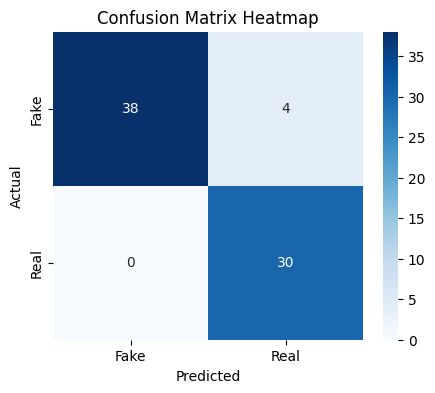

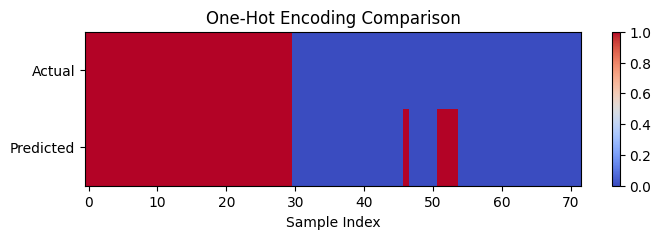

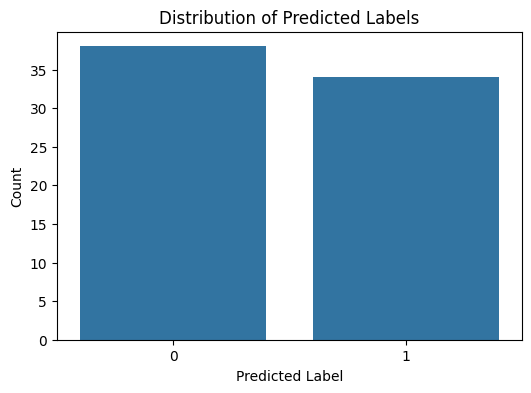

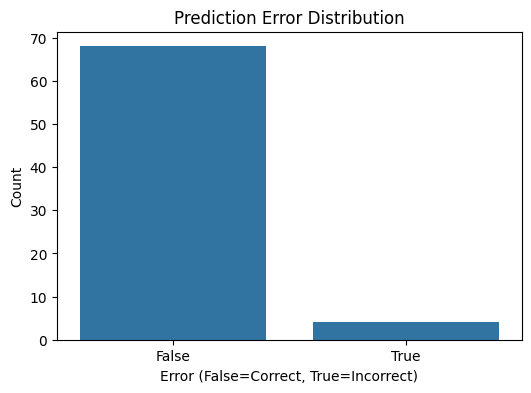

In [58]:
# Analysis and Visualization for Look_real vs predicted_look_real
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# Load the dataframe if not already loaded
df_output = pd.read_csv("../../../data/evaluation_role_output.csv")

# Confusion Matrix and Metrics
cm = confusion_matrix(df_output['look_Real'], df_output['predicted_look_Real'])
acc = accuracy_score(df_output['look_Real'], df_output['predicted_look_Real'])
prec = precision_score(df_output['look_Real'], df_output['predicted_look_Real'])
rec = recall_score(df_output['look_Real'], df_output['predicted_look_Real'])

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print("Classification Report:\n", classification_report(df_output['look_Real'], df_output['predicted_look_Real']))

# Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Hot Encoder Plot
lb = LabelBinarizer()
y_true_hot = lb.fit_transform(df_output['look_Real'])
y_pred_hot = lb.transform(df_output['predicted_look_Real'])
plt.figure(figsize=(8,2))
plt.imshow(np.vstack([y_true_hot.T, y_pred_hot.T]), aspect='auto', cmap='coolwarm')
plt.yticks([0,1], ['Actual', 'Predicted'])
plt.xlabel('Sample Index')
plt.title('One-Hot Encoding Comparison')
plt.colorbar()
plt.show()

# Additional Analysis: Distribution of predictions
plt.figure(figsize=(6,4))
sns.countplot(x='predicted_look_Real', data=df_output)
plt.title('Distribution of Predicted Labels')
plt.xlabel('Predicted Label')
plt.ylabel('Count')
plt.show()

# Additional: Compare prediction errors
df_output['error'] = df_output['look_Real'] != df_output['predicted_look_Real']
plt.figure(figsize=(6,4))
sns.countplot(x='error', data=df_output)
plt.title('Prediction Error Distribution')
plt.xlabel('Error (False=Correct, True=Incorrect)')
plt.ylabel('Count')
plt.show()

# How to incorporate cosine similarity score